# Vanilla GAN on MNIST
Generative Adversarial Network trained on handwritten digits.
Generator: noise → fake images. Discriminator: real vs fake classification.

## 1. Setup

In [43]:
import sys
import torch
print('Python:', sys.version)
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
print('MPS available:', torch.backends.mps.is_available())

Python: 3.13.2 | packaged by Anaconda, Inc. | (main, Feb  6 2025, 12:55:35) [Clang 14.0.6 ]
PyTorch: 2.11.0
CUDA available: False
MPS available: True


In [44]:
%pip install torchvision --quiet

Note: you may need to restart the kernel to use updated packages.


In [45]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display, clear_output
from tqdm.notebook import tqdm
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

from model import Generator, Discriminator, weights_init
import utils

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

## 2. Configuration

In [46]:
config = {
    'latent_dim':       100,
    'batch_size':        64,
    'num_epochs':        50,
    'lr':            0.0002,
    'betas':   (0.5, 0.999),
    'checkpoint_every':  10,
    'data_dir':    './data',
    'output_dir': './outputs',
    'log_path':  './logs/training_log.csv',
}

os.makedirs('logs', exist_ok=True)
paths = utils.setup_output_dirs(config['output_dir'])

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print('Device:', device)

Device: mps


## 3. Dataset

In [47]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),  # [0,1] -> [-1,1]
])
dataset = datasets.MNIST(root=config['data_dir'], train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=config['batch_size'], shuffle=True,
                        num_workers=0, pin_memory=False)
print(f'Dataset size: {len(dataset)} images')

Dataset size: 60000 images


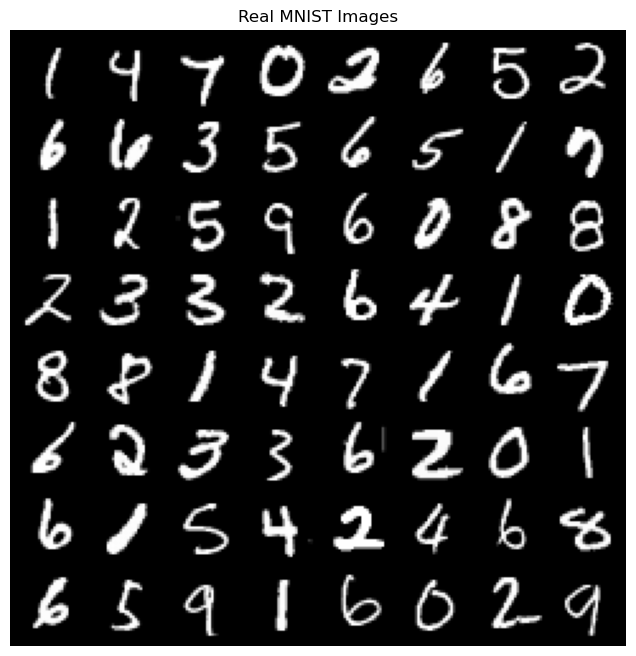

In [48]:
# Visualize a batch of real MNIST images
real_batch, labels = next(iter(dataloader))
grid = make_grid(real_batch[:64].view(-1, 1, 28, 28), nrow=8, normalize=True, padding=2)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
plt.title('Real MNIST Images')
plt.axis('off')
plt.show()

## 4. Architecture

```
z ~ N(0, I)  ──►  [Generator]  ──►  fake_img (784)
                                         │
real_img (784)  ─────────────────────────┤
                                         ▼
                              [Discriminator]  ──►  P(real) ∈ [0,1]
```

### Generator (1,486,352 params)
| Layer | In | Out | Activation |
|-------|-----|-----|------------|
| Linear | 100 | 256 | LeakyReLU(0.2) |
| Linear | 256 | 512 | LeakyReLU(0.2) |
| Linear | 512 | 1024 | LeakyReLU(0.2) |
| Linear | 1024 | 784 | **Tanh** → outputs in [-1, 1] |

### Discriminator (201,217 params)
| Layer | In | Out | Activation |
|-------|-----|-----|------------|
| Linear | 784 | 256 | ReLU |
| Linear | 256 | 1 | **Sigmoid** → outputs P(real) ∈ [0, 1] |

**Final layer notes:**
- **Generator Tanh**: maps output to `[-1, 1]`, matching the normalized MNIST pixel range (images are normalized with mean=0.5, std=0.5)
- **Discriminator Sigmoid**: squashes the logit to a probability. A value near `1` means the discriminator thinks the input is real; near `0` means fake

In [52]:
import os, importlib, model as _m                                                                                                                                                                                
print(os.getcwd())          # check working dir                                                                                                                                                                  
importlib.reload(_m)                                                                                                                                                                                             
from model import Generator, Discriminator, weights_init 
print(os.getcwd())
generator     = Generator(latent_dim=config['latent_dim']).to(device)
discriminator = Discriminator().to(device)
generator.apply(weights_init)
discriminator.apply(weights_init)

g_params = sum(p.numel() for p in generator.parameters())
d_params = sum(p.numel() for p in discriminator.parameters())
print(f'Generator     params: {g_params:,}')
print(f'Discriminator params: {d_params:,}')
print('\nGenerator:')
print(generator)
print('\nDiscriminator:')
print(discriminator)

/Users/hari/Documents/projects/GAN
/Users/hari/Documents/projects/GAN
Generator     params: 1,486,352
Discriminator params: 233,985

Generator:
Generator(
  (net): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)

Discriminator:
Discriminator(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=128, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


## 5. Training

In [53]:
criterion   = nn.BCELoss()
g_optimizer = torch.optim.Adam(generator.parameters(),     lr=config['lr'], betas=config['betas'])
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=config['lr'], betas=config['betas'])

fixed_noise = torch.randn(64, config['latent_dim'], device=device)

g_losses_epoch = []
d_losses_epoch = []

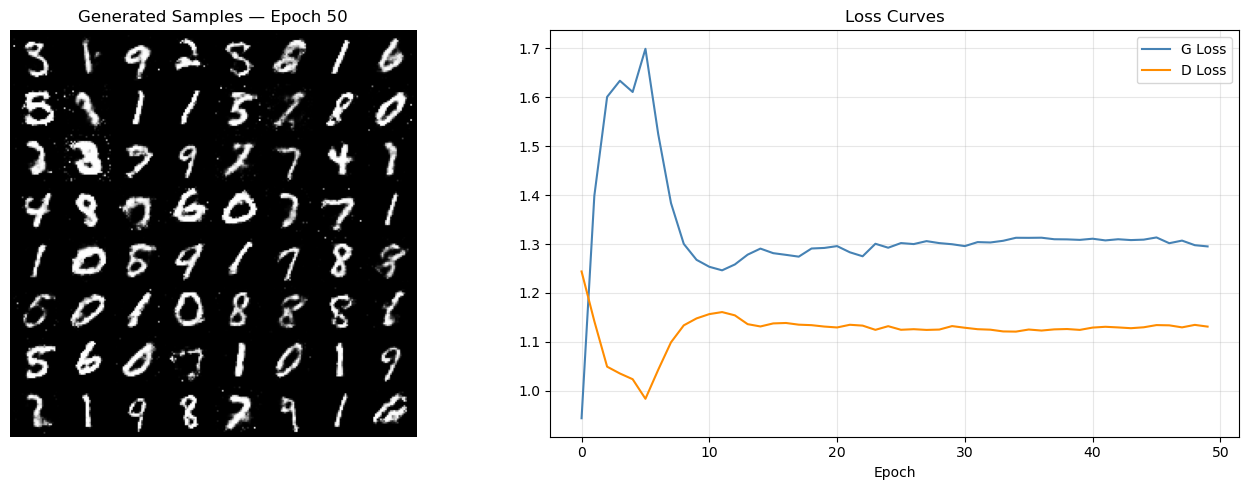

Epoch [50/50]  G Loss: 1.2951  D Loss: 1.1313
Training complete.


In [54]:
for epoch in range(1, config['num_epochs'] + 1):
    g_losses_batch = []
    d_losses_batch = []

    for real_batch, _ in tqdm(dataloader, desc=f'Epoch {epoch}/{config["num_epochs"]}', leave=False):
        real_imgs  = real_batch.view(-1, 784).to(device)
        batch_size = real_imgs.size(0)

        real_labels = torch.full((batch_size, 1), 0.9, device=device)  # label smoothing
        fake_labels = torch.zeros(batch_size, 1, device=device)

        # --- Discriminator update ---
        d_optimizer.zero_grad()
        d_loss_real = criterion(discriminator(real_imgs), real_labels)
        z = torch.randn(batch_size, config['latent_dim'], device=device)
        d_loss_fake = criterion(discriminator(generator(z).detach()), fake_labels)
        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        d_optimizer.step()

        # --- Generator update ---
        g_optimizer.zero_grad()
        z = torch.randn(batch_size, config['latent_dim'], device=device)
        g_loss = criterion(discriminator(generator(z)), torch.ones(batch_size, 1, device=device))
        g_loss.backward()
        g_optimizer.step()

        g_losses_batch.append(g_loss.item())
        d_losses_batch.append(d_loss.item())

    epoch_g = sum(g_losses_batch) / len(g_losses_batch)
    epoch_d = sum(d_losses_batch) / len(d_losses_batch)
    g_losses_epoch.append(epoch_g)
    d_losses_epoch.append(epoch_d)

    # Save grid and log
    with torch.no_grad():
        fake_samples = generator(fixed_noise).cpu()
    grid = utils.save_image_grid(fake_samples, epoch, config['output_dir'])
    utils.log_losses(epoch, epoch_g, epoch_d, config['log_path'])

    # Checkpoint
    if epoch % config['checkpoint_every'] == 0:
        utils.save_checkpoint(
            generator, discriminator, g_optimizer, d_optimizer,
            epoch, {'g_loss': epoch_g, 'd_loss': epoch_d},
            paths['checkpoints'],
        )

    # Live display
    clear_output(wait=True)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    grid_np = grid.permute(1, 2, 0).numpy()
    axes[0].imshow(grid_np, cmap='gray')
    axes[0].set_title(f'Generated Samples — Epoch {epoch}')
    axes[0].axis('off')
    axes[1].plot(g_losses_epoch, label='G Loss', color='steelblue')
    axes[1].plot(d_losses_epoch, label='D Loss', color='darkorange')
    axes[1].set_title('Loss Curves')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f'Epoch [{epoch}/{config["num_epochs"]}]  G Loss: {epoch_g:.4f}  D Loss: {epoch_d:.4f}')

utils.plot_loss_curves(g_losses_epoch, d_losses_epoch, config['output_dir'], save=True)
print('Training complete.')

## 6. Results

In [ ]:
# Final loss curves
img = mpimg.imread(os.path.join(config['output_dir'], 'plots', 'loss_curves.png'))
plt.figure(figsize=(9, 5))
plt.imshow(img)
plt.axis('off')
plt.show()

In [ ]:
# Training progression: epoch 1 vs 25 vs 50
checkpoints_to_show = [1, 25, config['num_epochs']]
fig, axes = plt.subplots(1, len(checkpoints_to_show), figsize=(15, 5))
for ax, ep in zip(axes, checkpoints_to_show):
    path = os.path.join(config['output_dir'], 'images', f'epoch_{ep:03d}.png')
    if os.path.exists(path):
        ax.imshow(mpimg.imread(path), cmap='gray')
        ax.set_title(f'Epoch {ep}')
    else:
        ax.set_title(f'Epoch {ep} (not saved)')
    ax.axis('off')
plt.suptitle('Generation Progression', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Fresh sample from a new random noise batch
generator.eval()
with torch.no_grad():
    new_noise  = torch.randn(64, config['latent_dim'], device=device)
    new_samples = generator(new_noise).cpu()
generator.train()

new_imgs = (new_samples.view(-1, 1, 28, 28) + 1) / 2
grid = make_grid(new_imgs, nrow=8, normalize=False, padding=2)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
plt.title('Fresh Generated Samples (Post-Training)')
plt.axis('off')
plt.show()

## 7. Checkpoint Loading Demo

In [ ]:
# Demonstrate loading a checkpoint to resume or evaluate
G2 = Generator(latent_dim=config['latent_dim']).to(device)
D2 = Discriminator().to(device)
g_opt2 = torch.optim.Adam(G2.parameters(), lr=config['lr'], betas=config['betas'])
d_opt2 = torch.optim.Adam(D2.parameters(), lr=config['lr'], betas=config['betas'])

ckpt_path = os.path.join(paths['checkpoints'], f'checkpoint_epoch_{config["checkpoint_every"]:03d}.pth')
if os.path.exists(ckpt_path):
    epoch_loaded, g_loss_ckpt, d_loss_ckpt = utils.load_checkpoint(
        ckpt_path, G2, D2, g_opt2, d_opt2, device
    )
    print(f'Loaded checkpoint from epoch {epoch_loaded}')
    print(f'  G loss at checkpoint: {g_loss_ckpt:.4f}')
    print(f'  D loss at checkpoint: {d_loss_ckpt:.4f}')
else:
    print(f'Checkpoint not found at {ckpt_path}. Run training first.')

## 8. Next Steps

Ideas to extend this project:

- **Deeper discriminator** — add more layers or dropout for stronger regularization
- **BatchNorm in Generator** — add `nn.BatchNorm1d` after linear layers for more stable training
- **DCGAN** — replace fully-connected layers with Conv2d/ConvTranspose2d for sharper images
- **Conditional GAN (cGAN)** — condition G and D on class labels to control which digit is generated
- **WGAN-GP** — replace BCELoss with Wasserstein distance + gradient penalty to fix mode collapse
- **Latent interpolation** — interpolate between two z vectors to visualize the latent space geometry
- **Training GIF** — stitch `outputs/images/epoch_*.png` into an animated GIF showing learning progress